In [1]:
# from https://juliaphysics.github.io/SolidStateDetectors.jl/stable/tutorials/complete_simulation_chain_IVC/
using Plots
using SolidStateDetectors
using Unitful
using UnitfulAtomic
using RadiationDetectorSignals


In [2]:
#cfdict = SolidStateDetectors.parse_config_file("P42575A.config")
#using YAML
#YAML.write_file("SSD_config_file.yaml", cfdict)

In [3]:
# cd("/Users/kevinhbhimani/Desktop/siggen_ccd/config_files/")
# SolidStateDetectors.readsiggen("P42575A.config")

In [4]:
#example on how to overwrite a function in package

using SolidStateDetectors: ArbitraryDriftModificationVolume, SSDFloat
import SolidStateDetectors: modulate_driftvector

function modulate_driftvector(sv::CartesianVector{T}, pt::CartesianPoint{T}, tl::ArbitraryDriftModificationVolume{T}, ::Type{Val{4}})::CartesianVector{T} where {T <: SSDFloat}
    return CartesianVector{T}(sv.x, sv.y, max(0,sv.z)) ./100
end

modulate_driftvector (generic function with 6 methods)

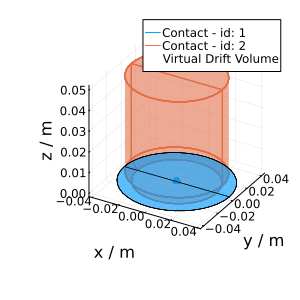

In [5]:
T = Float64
# sim = Simulation{T}("config_files/P42575A.config")
sim = Simulation{T}("EH-Drift/config_files/SSD_config_file.yaml")
plot(sim.detector, size = (300, 300)) #, show_passives = false
det=plot!(sim.detector.virtual_drift_volumes[1].geometry, fillalpha = 0.4, lw = 1, label = "Virtual Drift Volume")
 # plot!(camera = (0,0), zlims = (0,0.0005))
# savefig(det,"file.png")


In [6]:
sim.detector.passives[1].charge_density_model

LoadError: MethodError: no method matching getindex(::Missing, ::Int64)

In [ ]:
@time simulate!(sim, depletion_handling = true, refinement_limits = [0.2,0.1,0.05,0.01,0.0001])

In [176]:
plot(sim.electric_field)
plot_electric_fieldlines!(sim)

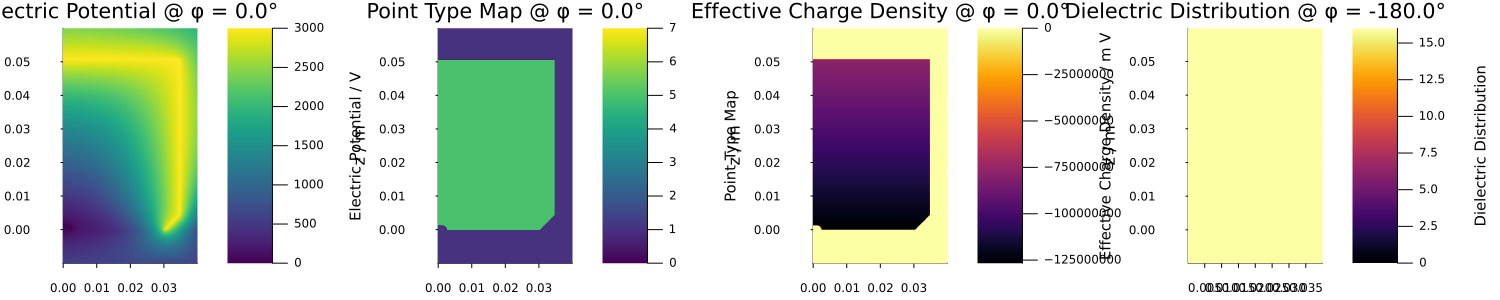

In [163]:
plot(
    plot(sim.electric_potential), # initial electric potential (boundary conditions)
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1500, 300)
)

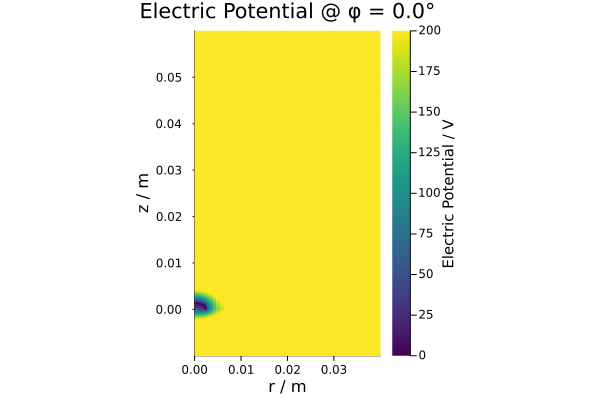

In [165]:
plot(sim.electric_potential, clims = (0,200))

In [155]:
# for z in sim.electric_field.grid.z.ticks
#     println(z)
# end

In [156]:
T = Float64

# this is the center position of the charge cloud
center = CartesianPoint{T}( 0.015, deg2rad(0), 10^(-6))

# this is the energy of the charge cloud
E0 = SolidStateDetectors.to_internal_units(5000u"keV")

# here we create an array positions, consisting of the center charge and N points
# equally distributed on a sphere with given radius
N = 1000
radius = T(10^-6) #in m
points = vcat([center], SolidStateDetectors.create_regular_sphere(center, N, radius))

# Here you can weight the energy distribution onto the charges
# E = T[i == 1 ? 1000 : 1 for i in eachindex(points)]; # weighting the center charge more
E = T[1 for i in eachindex(points)];                 # equal weighting

# make sure that the sum of the energies correspond to the one you want
finalE = E ./ sum(E) * E0

# then create the charge cloud for the simulation
nbcc = SolidStateDetectors.NBodyChargeCloud{T, 1, NTuple{1, Int}}(points, finalE, Tuple([length(E) - 1]))
# create an Event for SSD 
evt = Event(nbcc)

# simulate the event
@time simulate!(evt, sim, Δt = 1u"ns", max_nsteps = 6000, diffusion = true, self_repulsion = true)

 54.408909 seconds (82.39 M allocations: 11.728 GiB, 4.99% gc time)


[ Info: Saved animation to /Users/kevinhbhimani/Desktop/SSD_sims/tmp.gif


Plots.AnimatedGif("/Users/kevinhbhimani/Desktop/SSD_sims/tmp.gif")
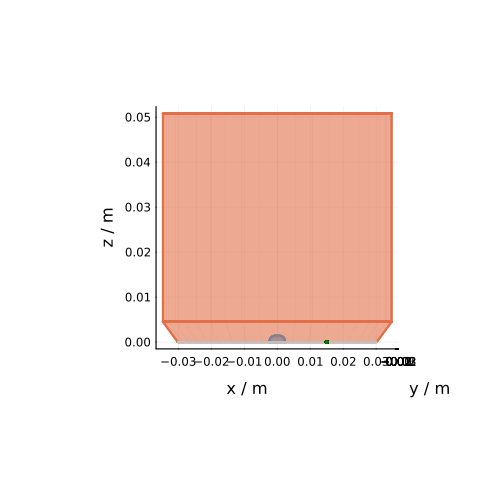

In [157]:
@gif for i in 1:10:500
plot(sim.detector, size = (500,500))
let p = getindex.(getproperty.(evt.drift_paths,:e_path),min.(i, length.(getproperty.(evt.drift_paths,:e_path))))
    scatter!(getindex.(p,1), getindex.(p,2), getindex.(p,3), color = :red, ms = 2, msw = 0)
end
let p = getindex.(getproperty.(evt.drift_paths,:h_path),min.(i, length.(getproperty.(evt.drift_paths,:h_path))))
    scatter!(getindex.(p,1), getindex.(p,2), getindex.(p,3), color = :green, ms = 2, msw = 0)
end
plot!(legend = false, camera = (0,0))
end


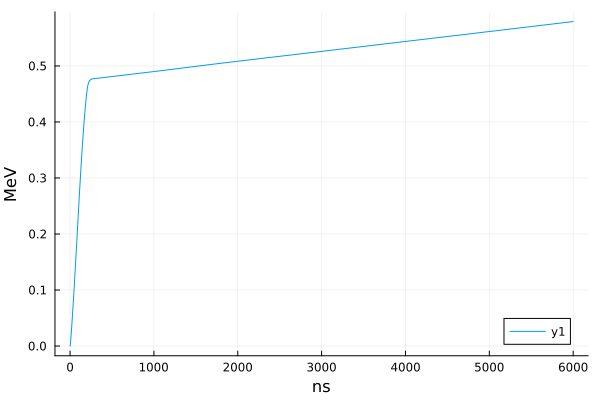

In [158]:
waveform=plot(evt.waveforms[1].time, uconvert.(u"MeV", evt.waveforms[1].signal*2.95u"V")) # ionization energy of Ge

In [159]:
savefig(waveform,"waveform.png")

"/Users/kevinhbhimani/Desktop/SSD_sims/waveform.png"